In [39]:
from util import go_to_project_root
go_to_project_root()

CWD changed to the project root: /home/epsilon/Documents/doctorado/S2/ENSTA630/tareas/HW1


# Pregunta 4

In [40]:
import numpy as np
import matplotlib.pyplot as plt 

from source.models.arma import ARMA
from source.utils import plot as uplot 
from source.data.loaders import create_dataset
from source.optimize.conditionalss import conditional_square_sum
from source.optimize.likelihood import maximum_likelihood_estimation
from source.optimize.parallel import parallel_bootstrap_hr
from source.utils.plot import plot_forecast

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
dataset = create_dataset('./data/hmw1_25.txt', problem=4)

[INFO] Data loaded successfully!


✅ Successfully saved figure to ./presentation/figures/p4/series_raw.pdf


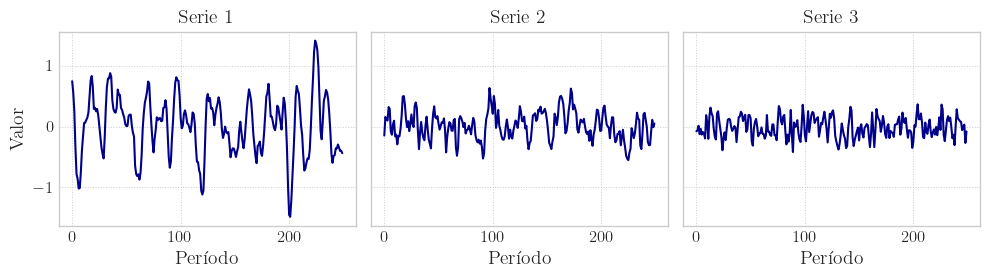

In [118]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
fig, axes = uplot.plot_simulation_paths(dataset, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/series_raw.pdf')

In [ ]:
criteria = 'hqic' # hqic bic aic
results_0 = parallel_bootstrap_hr(dataset[:, 0], 
                                  iterations=500, 
                                  j_max=20, 
                                  sampling='parametric',
                                  criteria=criteria,
                                  n_jobs=8)

results_1 = parallel_bootstrap_hr(dataset[:, 1], 
                                    iterations=500, 
                                    j_max=20, 
                                    sampling='parametric',
                                    criteria=criteria,
                                    n_jobs=8)

results_2 = parallel_bootstrap_hr(dataset[:, 2], 
                                    iterations=500, 
                                    j_max=20, 
                                    sampling='parametric',
                                    criteria=criteria,
                                    n_jobs=8)

Starting 500-iteration parallel bootstrap...
Fitting base model to original data for parametric sampling...


Searching for best (p,q) via HQIC [Fast]:   0%|          | 0/440 [00:00<?, ?it/s]

Searching for best (p,q) via HQIC [Fast]: 100%|██████████| 440/440 [00:00<00:00, 4997.98it/s]


Fast search complete! Best OLS Model: ARMA(2,0). Refining with MLE...



Base model found: ARMA(2,0). Generating bootstrap series...


...

Searching for best (p,q) via HQIC [Fast]: 100%|██████████| 440/440 [00:00<00:00, 4724.28it/s]


Fast search complete! Best OLS Model: ARMA(1,2). Refining with MLE...



Base model found: ARMA(1,2). Generating bootstrap series...


Processing bootstrap iterations: 100%|██████████| 500/500 [02:56<00:00,  2.83it/s]



Bootstrap complete! Most stable pair: (1,2) [129/500 successful iterations]
Refitting the final model on the original data using MLE...


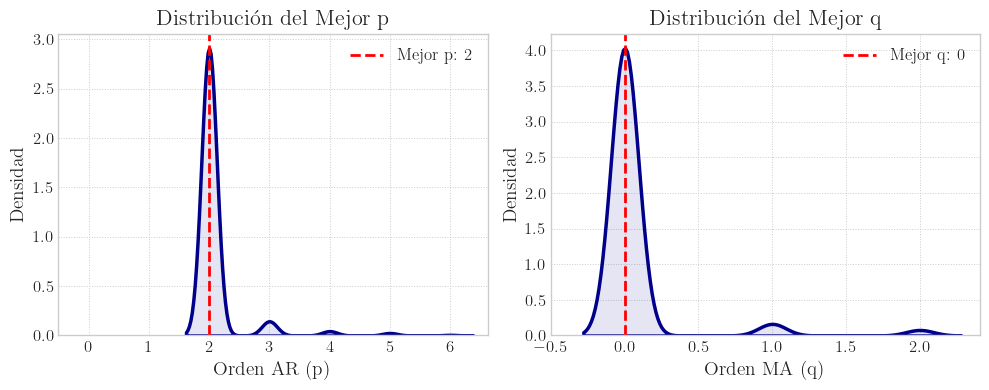

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_0.pdf


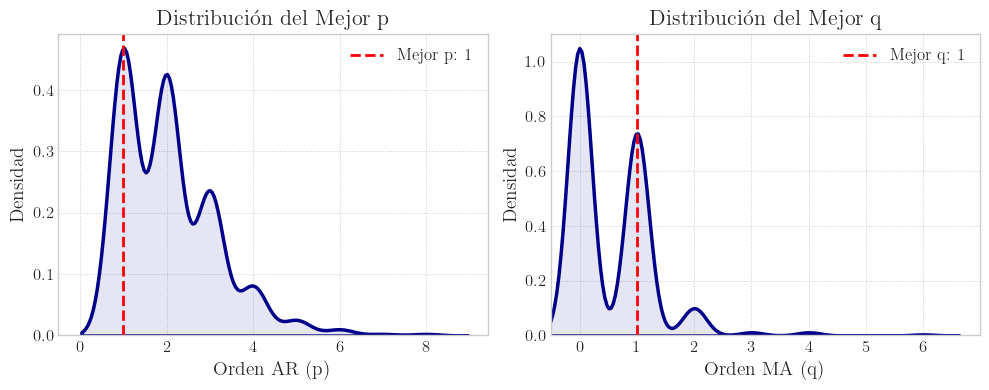

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_1.pdf


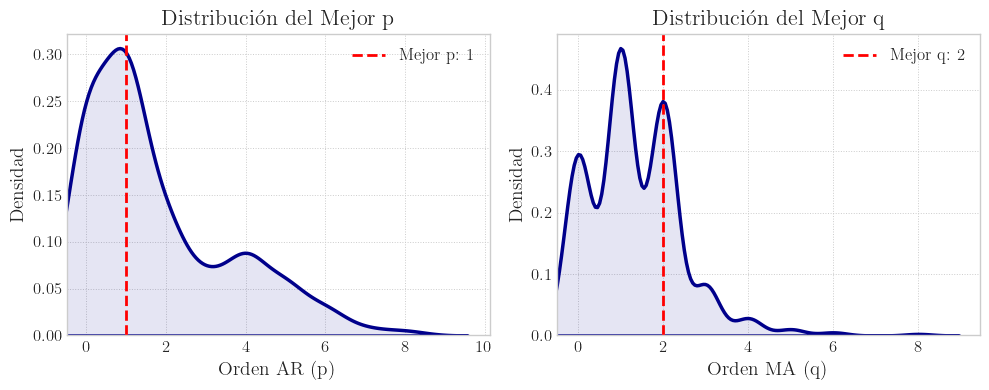

✅ Successfully saved figure to ./presentation/figures/p4/pq_hqic_2.pdf


In [113]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_0, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_0.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_1, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_1.pdf'.format(criteria))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig, axes = uplot.plot_bootstrap_kde(results_2, fig=fig, axes=axes)
uplot.save_figure(fig, './presentation/figures/p4/pq_{}_2.pdf'.format(criteria))

In [122]:
print(results_0['model'])

             ARMA(2, 0) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : 0.0137
Sigma (Unc. Std.)        : 3.4438
Error Std Dev (sigma)    : 0.1405
Constant (c)             : 0.0023
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 1.5788
  phi_2    = -0.7456
--------------------------------------------------
MA Coefficients (theta):
  (No MA coefficients)


In [123]:
print(results_1['model'])

             ARMA(1, 1) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : 0.0163
Sigma (Unc. Std.)        : 0.2271
Error Std Dev (sigma)    : 0.1390
Constant (c)             : 0.0066
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = 0.5932
--------------------------------------------------
MA Coefficients (theta):
  theta_1    = 0.4462


In [124]:
print(results_2['model'])

             ARMA(1, 2) Model Summary             
Is Stationary            : True
Mu (Unc. Mean)           : -0.0114
Sigma (Unc. Std.)        : 0.1672
Error Std Dev (sigma)    : 0.1342
Constant (c)             : -0.0188
--------------------------------------------------
AR Coefficients (phi):
  phi_1    = -0.6491
--------------------------------------------------
MA Coefficients (theta):
  theta_1    = 1.3910
  theta_2    = 0.4755


In [110]:
times = np.arange(len(dataset[:, 1]))

H = 5
x_train = dataset[:-H, 1]
t_train = times[:-H]
x_test = dataset[-H:, 1]
t_test = times[-H:]

In [103]:
pi_pred, pi_low, pi_up = results_1['model'].forecast_arma(x_train, h=H)

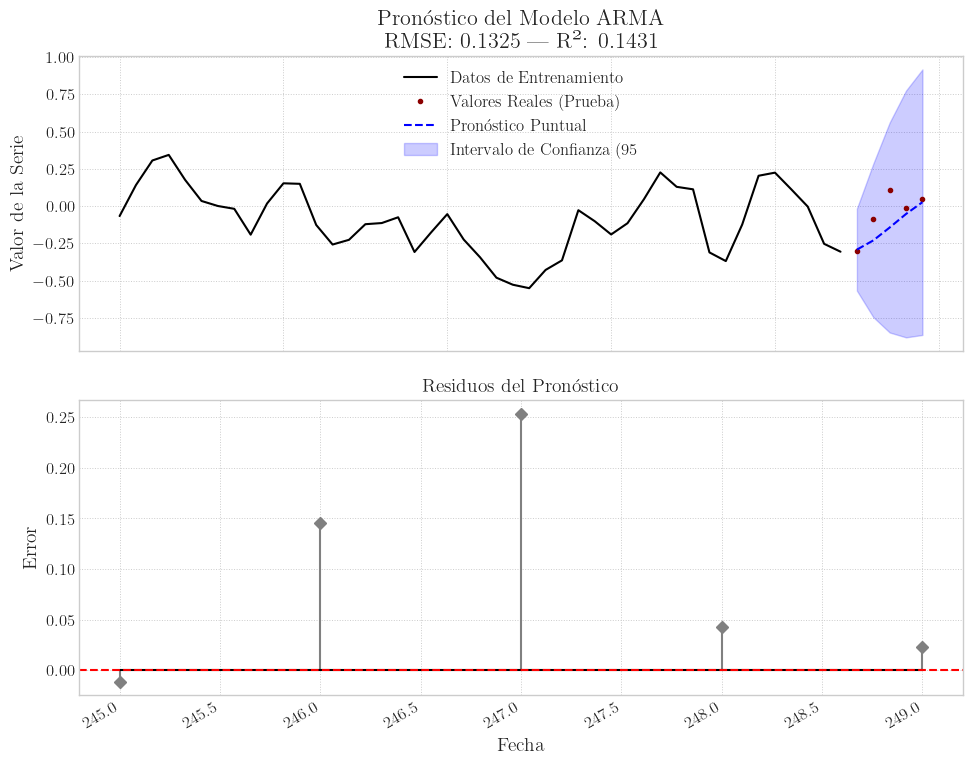

✅ Successfully saved figure to ./presentation/figures/p4/forecasting_hqic_0.pdf


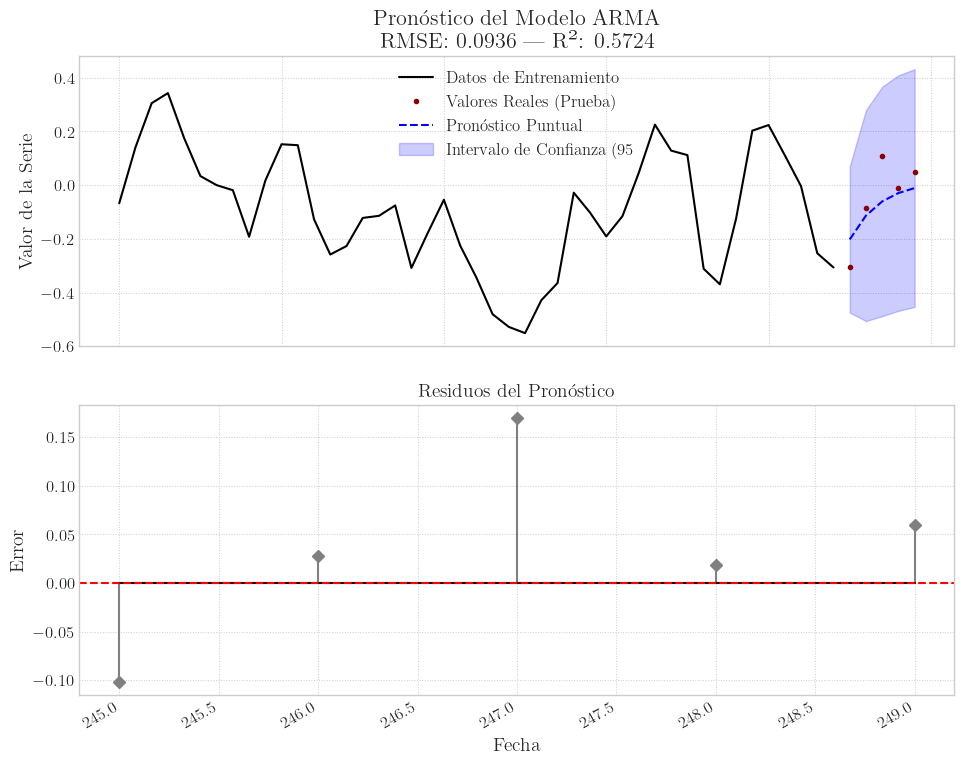

✅ Successfully saved figure to ./presentation/figures/p4/forecasting_hqic_1.pdf


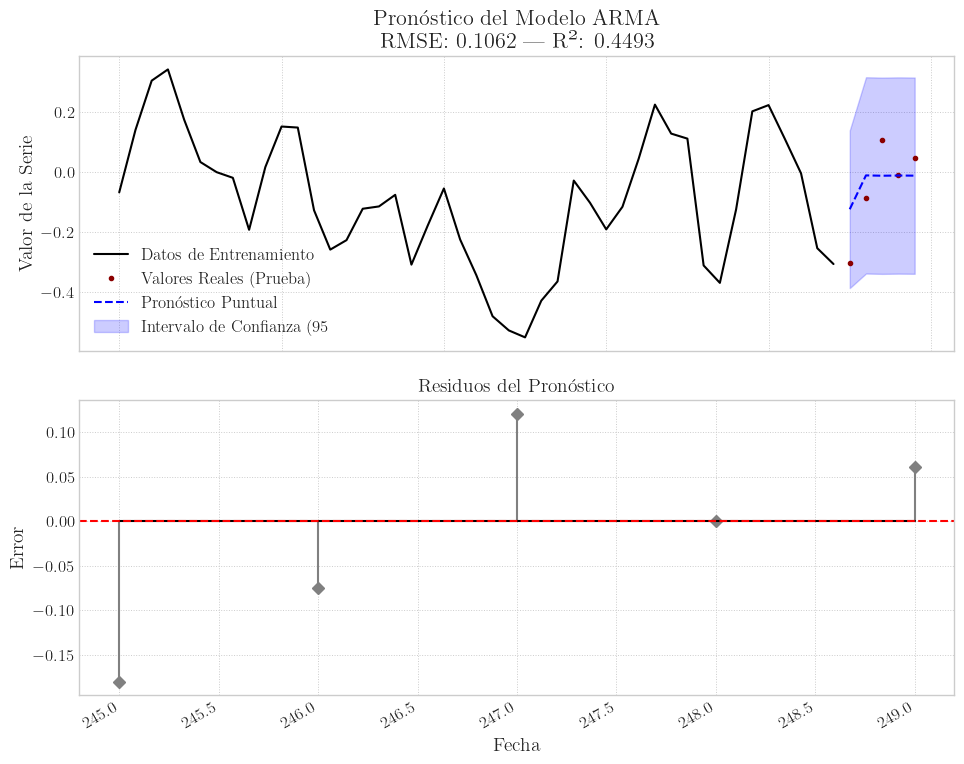

✅ Successfully saved figure to ./presentation/figures/p4/forecasting_hqic_2.pdf


In [112]:
count = 0
for r in [results_0, results_1, results_2]:

    pi_pred, pi_low, pi_up = r['model'].forecast_arma(x_train, h=H)

    START = 200
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    fig, axes = plot_forecast(t_train[START:], 
                x_train[START:],
                t_test,
                x_test,
                pi_pred,
                pi_low,
                pi_up, 
                model_name="ARMA", 
                fig=fig, 
                axes=axes)
    uplot.save_figure(fig, './presentation/figures/p4/forecasting_{}_{}.pdf'.format(criteria, count))
    count+=1

### Paper Approach

In [ ]:
criteria = 'hqic' # hqic bic aic
results_0 = parallel_bootstrap_hr(dataset[:, 0], 
                                  iterations=500, 
                                  j_max=20, 
                                  sampling='parametric',
                                  criteria=criteria,
                                  ols_on=True,
                                  n_jobs=8)

results_1 = parallel_bootstrap_hr(dataset[:, 1], 
                                    iterations=500, 
                                    j_max=20, 
                                    sampling='parametric',
                                    criteria=criteria,
                                    ols_on=True,
                                    n_jobs=8)

results_2 = parallel_bootstrap_hr(dataset[:, 2], 
                                    iterations=500, 
                                    j_max=20, 
                                    sampling='parametric',
                                    criteria=criteria,
                                    ols_on=True,
                                    n_jobs=8)